In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import  pyplot as plt 

In [2]:
base_dir = f"../../artifacts/2024-03-s22/experiments/accuracy-curves/3-vgg16-models"

In [3]:
def read_data(dataset, model, layer, logit_mod, basis_name, gamma):
    model = model
    layer = layer
    df = pd.read_csv(
        f"{base_dir}/{dataset}/{model}/{logit_mod}/{layer}/{basis_name}--gamma{gamma}.csv"
    )
    return df

read_data(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    layer="features.23",
    logit_mod="winninglogit",
    basis_name="pca",
    gamma=0.25
)

,layer,k,acc
0,features.23,1,0.183333
1,features.23,2,0.113333
2,features.23,3,0.303333
3,features.23,4,0.396667
4,features.23,5,0.430000
5,features.23,6,0.476667
6,features.23,7,0.653333
7,features.23,8,0.743333
8,features.23,9,0.796667
9,features.23,10,0.823333


In [4]:
import re
def find_ratios(names):
    
    arr = []
    
    for t in names:
        m = re.match(r"pca([\.\d]+)prcasortabs", t)
        if m:
            arr.append(float(m.group(1)))
            
    
    return arr

find_ratios([
        "pca",
        "prcasortabs",
        "pca0.1prcasortabs",
        "pca0.25prcasortabs",
        "pca0.5prcasortabs",
        "pca1.0prcasortabs",
    ])

[0.1, 0.25, 0.5, 1.0]

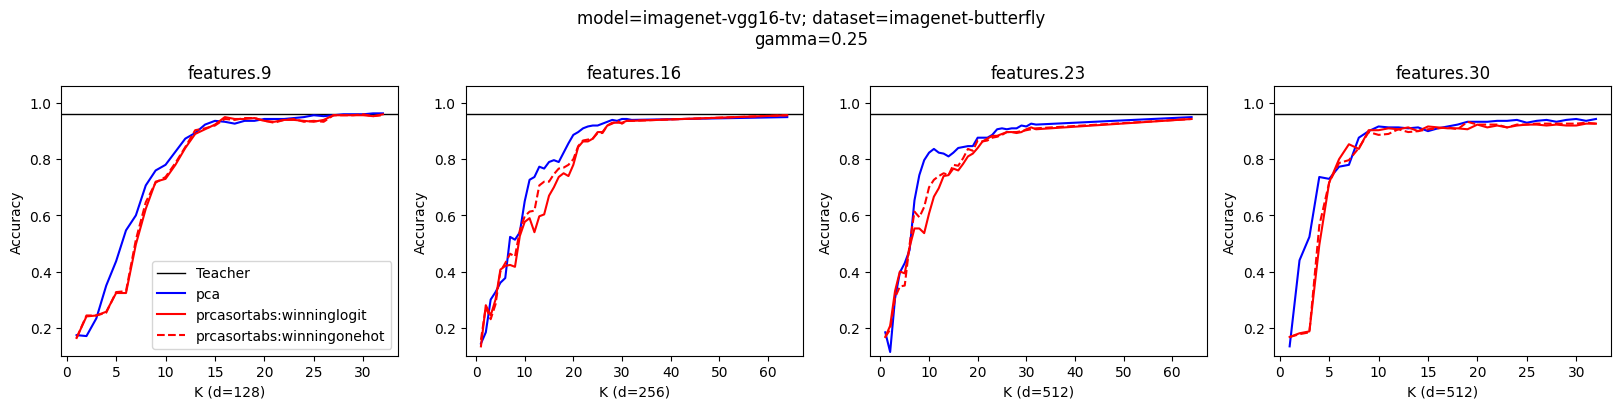

In [15]:
def alias(name):
    return name
    if "pca" in name:
        return "PCA"
    elif "prca" in name:
        gamma = name.split("--gamma")[1]
        return f"PRCA-sortabs($\\gamma={gamma}$)"
    else:
        raise

def ls(name, logit_mod):
    if name == "pca":
        return "-"
    elif name == "prcasortabs":
        if logit_mod == "winninglogit":
            return "-"
        else:
            return "--"
    
def viz(
    dataset,
    model,
    arr_layers,
    gamma,
    arr_basis_names=[
       "pca",
       "prcasortabs",  
    ],
    
):
    
    ncols = len(arr_layers)
    plt.figure(figsize=(5*ncols, 3.5))
    plt.suptitle(f"model={model}; dataset={dataset}\ngamma={gamma}", y=1.1)

    
    
    
    arr_ratios = np.array(find_ratios(arr_basis_names))
    color_index = np.linspace(0.25, 1, len(arr_ratios))
    cmap_reds = mpl.colormaps.get_cmap("Reds")

    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prcasortabs":
            return "red"
        elif re.match(r"pca([\.\d]+)prcasortabs", name):
            ratio = float(re.match(r"pca([\.\d]+)prcasortabs", name).group(1))

            ix = np.argwhere(arr_ratios == ratio).reshape(-1)[0]
            return cmap_reds(color_index[ix])
            return mpl.colormaps.get_cmap("Reds")(ratio + 0.1)
        else:
            raise
        
    for lix, (layer, max_k) in enumerate(arr_layers):
        plt.subplot(1, ncols, lix +1)
        
        plt.title(layer)
        
        for bix, basis_name in enumerate(arr_basis_names):
            for logit_mod in ["winninglogit", "winningonehot"]:

                df = read_data(
                    dataset=dataset,
                    model=model,
                    layer=layer,
                    basis_name=basis_name,
                    logit_mod=logit_mod,
                    gamma=gamma,
                )
                dims = df.k.max()

                if bix == 0:
                    ref_acc = df[df.k == df.k.max()].acc.values[0]
                    plt.axhline(
                        ref_acc, ls="-", label="Teacher", 
                        color="k",
                        lw=1
                    )
                    plt.ylim([0.1, ref_acc+0.1])
                _df = df[df.k <= max_k]

                plt.plot(
                    _df.k,
                    _df.acc,
                    ls=ls(basis_name, logit_mod),
                    color=color(basis_name),
                    label=basis_name if basis_name == "pca" else f"{basis_name}:{logit_mod}"
                )
                plt.xlabel(f"K (d={dims})")
                
                if basis_name == "pca":
                    break

        plt.ylabel("Accuracy")
        
        if lix == 0:
            plt.legend()
viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    arr_layers=[
        ("features.9", 32),
        ("features.16", 64),
        ("features.23", 64),
        ("features.30", 32),
    ],
    arr_basis_names=[
        "pca",
        "prcasortabs",
    ],
    gamma=0.25
)

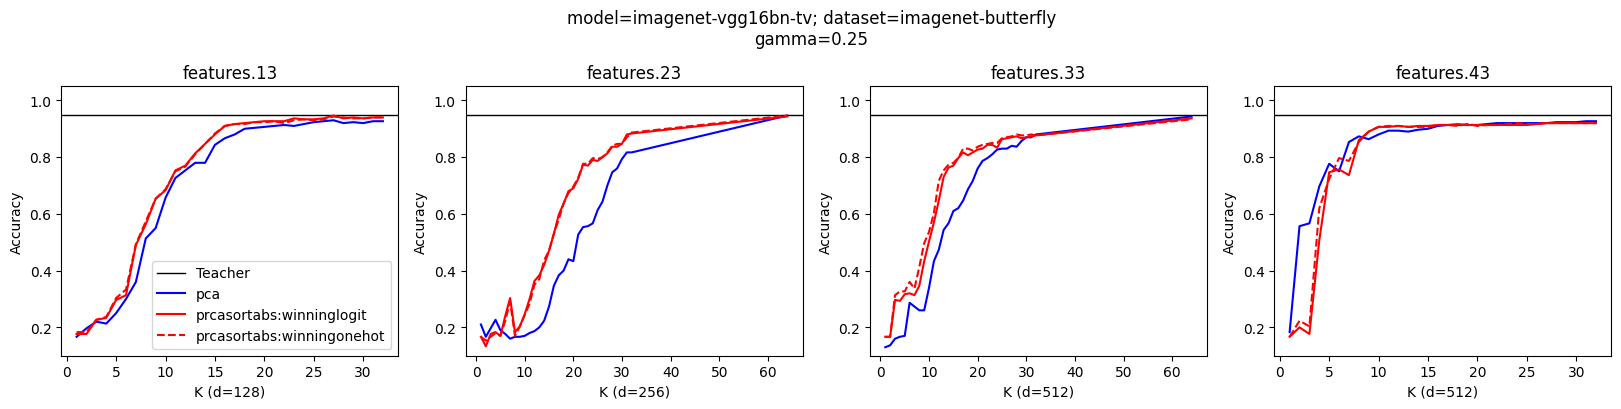

In [16]:
viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16bn-tv",
    arr_layers=[
        ("features.13", 32),
        ("features.23", 64),
        ("features.33", 64),
        ("features.43", 32),
    ],
    arr_basis_names=[
        "pca",
        "prcasortabs",
    ],
    gamma=0.25
)